In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [4]:
# ── Cell 1 : Load precipitation data ─────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr
import glob
import warnings
warnings.filterwarnings("ignore")

PRECIP_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files = sorted(glob.glob(f'{PRECIP_DIR}/**/*.nc', recursive=True))
print(f"Found {len(nc_files)} precip files")

ds_p = xr.open_mfdataset(nc_files, combine='by_coords', engine='h5netcdf', chunks=None)

data_precip = ds_p['tp'].values.astype('float32')
lat         = ds_p['latitude'].values.astype('float32')
lon         = ds_p['longitude'].values.astype('float32')
times_pd    = pd.to_datetime(ds_p['time'].values)

ds_p.close()

print(f"data_precip : {data_precip.shape}  dtype={data_precip.dtype}")
print(f"lat         : {lat[0]} → {lat[-1]}  ({len(lat)} values)")
print(f"lon         : {lon[0]} → {lon[-1]}  ({len(lon)} values)")
print(f"time        : {str(times_pd[0])[:10]} → {str(times_pd[-1])[:10]}  ({len(times_pd)} days)")
print("Precip ready ✓")

Found 46 precip files
data_precip : (5612, 141, 161)  dtype=float32
lat         : 40.0 → 5.0  (141 values)
lon         : 60.0 → 100.0  (161 values)
time        : 1979-06-01 → 2024-09-30  (5612 days)
Precip ready ✓


In [5]:
# ── Cell 2 : Load wind data ───────────────────────────────────────────────────
import xarray as xr
import numpy as np

WIND_PATH = '/kaggle/input/datasets/divyanshyecho/era5-uv850-mean/wind_daily_uv850.nc'

ds_w = xr.open_dataset(WIND_PATH, engine='h5netcdf')

u_wind   = ds_w['u'].values.astype('float32')         # eastward  (5612, 141, 161)
v_wind   = ds_w['v'].values.astype('float32')         # northward (5612, 141, 161)
wspeed   = ds_w['speed'].values.astype('float32')     # magnitude (5612, 141, 161)
wdir     = ds_w['direction'].values.astype('float32') # toward    (5612, 141, 161)

ds_w.close()

print(f"u_wind  : {u_wind.shape}  dtype={u_wind.dtype}")
print(f"v_wind  : {v_wind.shape}  dtype={v_wind.dtype}")
print(f"wspeed  : {wspeed.shape}  dtype={wspeed.dtype}")
print(f"wdir    : {wdir.shape}  dtype={wdir.dtype}")

# quick alignment check
print(f"\nAlignment with precip:")
print(f"  shape match : {u_wind.shape == data_precip.shape}")
print("Wind ready ✓")

u_wind  : (5612, 141, 161)  dtype=float32
v_wind  : (5612, 141, 161)  dtype=float32
wspeed  : (5612, 141, 161)  dtype=float32
wdir    : (5612, 141, 161)  dtype=float32

Alignment with precip:
  shape match : True
Wind ready ✓


In [7]:
# ── Wind confirmation checks (run in check-6; uses already-loaded cubes) ──────
import numpy as np

print("="*70); print("CHECK 1 — NaNs / fill values / physical range"); print("="*70)
for name, arr in [('u', u_wind), ('v', v_wind), ('speed', wspeed)]:
    print(f"  {name:5s}: min={np.nanmin(arr):7.2f}  max={np.nanmax(arr):7.2f}  "
          f"mean={np.nanmean(arr):6.2f}  NaNs={int(np.isnan(arr).sum())}")
ok_range = (np.nanmax(np.abs(u_wind)) < 80) and (np.nanmax(np.abs(v_wind)) < 80)
print(f"  magnitudes plausible for 850 hPa (<80 m/s) : {ok_range}")

print("\n"+"="*70); print("CHECK 2 — speed == sqrt(u^2+v^2) ?"); print("="*70)
max_diff = float(np.nanmax(np.abs(np.sqrt(u_wind**2 + v_wind**2) - wspeed)))
print(f"  max |sqrt(u^2+v^2) - speed| = {max_diff:.4f} m/s  "
      f"({'OK' if max_diff < 1e-2 else 'MISMATCH — investigate'})")

print("\n"+"="*70); print("CHECK 3 — grid identity with precip (no flip / no regrid)"); print("="*70)
print(f"  wind shape == precip shape : {u_wind.shape == data_precip.shape}")
print(f"  lat : {lat[0]} -> {lat[-1]}   ({len(lat)} pts, descending={lat[0]>lat[-1]})")
print(f"  lon : {lon[0]} -> {lon[-1]}   ({len(lon)} pts)")

print("\n"+"="*70); print("CHECK 4 — time alignment + date->index map"); print("="*70)
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
months = times_pd.month
print(f"  n days                 : {len(times_pd)}")
print(f"  all within JJAS (6-9)? : {bool(((months>=6)&(months<=9)).all())}")
print(f"  range                  : {times_pd[0].date()} -> {times_pd[-1].date()}")
print(f"  monotonic increasing?  : {bool((np.diff(times_pd.values).astype('int64')>0).all())}")
print(f"  sample: 19790601 -> idx {date_to_idx.get('19790601')}   "
      f"20070815 -> idx {date_to_idx.get('20070815')}")

print("\n"+"="*70)
print("CHECK 5 — does the JJAS-mean 850 flow look like the monsoon?")
print("  (low-level SW monsoon -> u>0 eastward AND v>0 northward over the seas)")
print("="*70)
def box_mean(latmin, latmax, lonmin, lonmax):
    la = (lat >= latmin) & (lat <= latmax); lo = (lon >= lonmin) & (lon <= lonmax)
    return float(u_wind[:, la][:, :, lo].mean()), float(v_wind[:, la][:, :, lo].mean())
boxes = {'Arabian Sea   (5-15N, 60-70E)': (5,15,60,70),
         'Bay of Bengal (10-20N, 85-95E)': (10,20,85,95),
         'Monsoon trough(20-27N, 75-85E)': (20,27,75,85)}
for label,(a,b,c,d) in boxes.items():
    um, vm = box_mean(a,b,c,d)
    interp = ("eastward" if um>0 else "westward") + " & " + ("northward" if vm>0 else "southward")
    print(f"  {label}:  u={um:+5.2f}  v={vm:+5.2f} m/s  -> {interp}")
print("\n  Verdict: eastward (u>0) flow over the Arabian Sea / Bay of Bengal is THE")
print("  monsoon signature and confirms the u/v sign convention is correct.")

CHECK 1 — NaNs / fill values / physical range
  u    : min= -29.46  max=  38.43  mean=  4.62  NaNs=0
  v    : min= -34.35  max=  37.25  mean=  0.40  NaNs=0
  speed: min=   0.00  max=  41.01  mean=  6.62  NaNs=0
  magnitudes plausible for 850 hPa (<80 m/s) : True

CHECK 2 — speed == sqrt(u^2+v^2) ?
  max |sqrt(u^2+v^2) - speed| = 0.0000 m/s  (OK)

CHECK 3 — grid identity with precip (no flip / no regrid)
  wind shape == precip shape : True
  lat : 40.0 -> 5.0   (141 pts, descending=True)
  lon : 60.0 -> 100.0   (161 pts)

CHECK 4 — time alignment + date->index map
  n days                 : 5612
  all within JJAS (6-9)? : True
  range                  : 1979-06-01 -> 2024-09-30
  monotonic increasing?  : True
  sample: 19790601 -> idx 0   20070815 -> idx 3491

CHECK 5 — does the JJAS-mean 850 flow look like the monsoon?
  (low-level SW monsoon -> u>0 eastward AND v>0 northward over the seas)
  Arabian Sea   (5-15N, 60-70E):  u=+12.46  v=+1.49 m/s  -> eastward & northward
  Bay of Bengal

In [9]:
# ── SETUP : load + mask + threshold + labeling (run this FIRST) ───────────────
import numpy as np, pandas as pd, xarray as xr, glob, subprocess, warnings
from scipy import ndimage
warnings.filterwarnings("ignore")

subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

# --- load ERA5 ---
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))
print(f"found {len(nc_files)} files")
ds = xr.open_mfdataset(nc_files, combine='by_coords', engine='h5netcdf', chunks=None)

data_precip = ds['tp'].values.astype('float32')
lat  = ds['latitude'].values.astype('float32')
lon  = ds['longitude'].values.astype('float32')
times_pd = pd.to_datetime(ds['time'].values)
print(f"shape : {data_precip.shape}   time : {str(times_pd[0])[:10]} -> {str(times_pd[-1])[:10]}")

# --- Section 1 : India mask + per-grid threshold ---
RAINY_DAY_MIN, PERCENTILE, FLOOR_MM = 1.0, 99.0, 50.0
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_mask = (countries.mask(lon, lat).values == 98)
print(f"India cells : {india_mask.sum()} / {len(lat)*len(lon)}")

data_masked = np.where((data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
                       data_precip, np.nan).astype('float32')
jjas_mask   = (times_pd.month >= 6) & (times_pd.month <= 9)
per_grid_99 = np.nanpercentile(data_masked[jjas_mask, :, :], PERCENTILE, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99, FLOOR_MM).astype('float32')
per_grid_threshold[~india_mask] = 999.0

data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d = np.broadcast_to(per_grid_threshold[np.newaxis, :, :], data_precip.shape).copy()
c = (data_precip_safe > threshold_3d)
print(f"exceedance rate : {c.mean()*100:.3f}%")

# --- Section 2 : 8-connectivity labeling ---
struct8 = ndimage.generate_binary_structure(2, 2)
n_days, n_lat, n_lon = data_precip.shape
Label8  = np.zeros((n_days, n_lat, n_lon), dtype='int32')
NE8_raw = np.zeros(n_days, dtype='int32')
for k in range(n_days):
    lab, nr = ndimage.label(c[k].astype('int8'), structure=struct8)
    Label8[k] = lab; NE8_raw[k] = nr
print(f"mean NE = {NE8_raw.mean():.3f} objects/day   labeling done ✓")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 837.9 kB/s eta 0:00:00
found 46 files
shape : (5612, 141, 161)   time : 1979-06-01 -> 2024-09-30
India cells : 4452 / 22701
exceedance rate : 0.114%
mean NE = 2.434 objects/day   labeling done ✓


In [10]:
# ── Cell : MEAN tracker, NO fallback — canonical run_tracking_mean ────────────
# Identical to the fb variant except STEP 4 (a track with no overlap next day
# simply dies). Adds audit cols link_sh / link_score; keeps day_lbl.
# Run AFTER SETUP (needs Label8, NE8_raw, india_mask, lat, lon, times_pd).
import numpy as np, pandas as pd

OVERLAP_THRESH, MIN_TRACK_CELLS, DOMAIN_EXIT_FRAC = 0.10, 1, 0.50
n_days, n_lat, n_lon = data_precip.shape

def run_tracking_mean():
    track_stats_rows, merge_event_rows, split_event_rows = [], [], []
    active_tracks, births_per_date = {}, {}
    counters = {'track': 0, 'merge': 0, 'split': 0}

    def jjas_day_num(ts): return int((ts - pd.Timestamp(f"{ts.year}-06-01")).days + 1)

    def get_objects(day_idx):
        labeled, n_obj, objs = Label8[day_idx], NE8_raw[day_idx], {}
        for lbl in range(1, n_obj + 1):
            mask = (labeled == lbl); sz = int(mask.sum())
            if sz < MIN_TRACK_CELLS: continue
            r_, c_ = np.where(mask)
            objs[lbl] = {'size': sz,
                         'centroid': (float(lat[r_].mean()), float(lon[c_].mean())),
                         'outside': int((mask & ~india_mask).sum())}
        return objs

    def compute_overlaps(dt, dt1, ot, ot1):
        lab_t, lab_t1, pairs = Label8[dt], Label8[dt1], {}
        for li in ot:
            mi = (lab_t == li)
            for lj in np.unique(lab_t1[mi]):
                if lj == 0 or lj not in ot1: continue
                sh = int((mi & (lab_t1 == lj)).sum())
                if sh == 0: continue
                fwd, bwd = sh / ot[li]['size'], sh / ot1[lj]['size']
                pairs[(li, lj)] = (fwd, bwd, sh, (fwd + bwd) / 2.0)   # MEAN
        return pairs

    def domain_exit(o): return (o['outside'] / o['size']) > DOMAIN_EXIT_FRAC

    def new_track(di, lbl, o, start_type, split_from=-1):
        counters['track'] += 1; tnum, ts = counters['track'], times_pd[di]
        ds = ts.strftime('%Y%m%d')
        births_per_date[ds] = births_per_date.get(ds, 0) + 1
        tid = f"{ds}_{births_per_date[ds]:03d}"; clat, clon = o['centroid']
        row = {'track_num': tnum, 'track_id': tid, 'date': ds, 'year': ts.year,
               'jjas_day': jjas_day_num(ts), 'day_of_track': 0, 'size': o['size'],
               'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
               'merge_event': False, 'split_event': False, 'link_type': 'birth',
               'link_sh': 0, 'link_score': np.nan,
               'start_type': start_type, 'end_type': None, 'duration': None,
               'split_from_track': split_from, 'merge_into_track': -1, 'day_lbl': lbl}
        active_tracks[tnum] = {'track_id': tid, 'last_day': di, 'last_lbl': lbl,
                               'last_centroid': o['centroid'], 'last_size': o['size'],
                               'start_type': start_type, 'duration': 1,
                               'split_from': split_from, 'daily_rows': [row]}
        return tnum

    def extend_track(tnum, di, lbl, o, merge_event=False, split_event=False,
                     link_type='overlap', link_sh=0, link_score=np.nan):
        tr = active_tracks[tnum]; tr['duration'] += 1; ts = times_pd[di]; clat, clon = o['centroid']
        tr['daily_rows'].append(
            {'track_num': tnum, 'track_id': tr['track_id'], 'date': ts.strftime('%Y%m%d'),
             'year': ts.year, 'jjas_day': jjas_day_num(ts), 'day_of_track': tr['duration'] - 1,
             'size': o['size'], 'centroid_lat': round(clat, 3), 'centroid_lon': round(clon, 3),
             'merge_event': merge_event, 'split_event': split_event, 'link_type': link_type,
             'link_sh': int(link_sh),
             'link_score': (round(float(link_score), 4) if link_score == link_score else np.nan),
             'start_type': tr['start_type'], 'end_type': None, 'duration': None,
             'split_from_track': tr['split_from'], 'merge_into_track': -1, 'day_lbl': lbl})
        tr['last_day'], tr['last_lbl'] = di, lbl
        tr['last_centroid'], tr['last_size'] = o['centroid'], o['size']

    def terminate_track(tnum, end_type, merge_into=-1):
        tr = active_tracks[tnum]; dur = tr['duration']; rows = tr['daily_rows']
        for r in rows: r['duration'] = dur
        rows[-1]['end_type'] = end_type; rows[-1]['merge_into_track'] = merge_into
        track_stats_rows.extend(rows); del active_tracks[tnum]

    for lbl, o in get_objects(0).items():
        tn = new_track(0, lbl, o, 'season_start')
        if domain_exit(o): terminate_track(tn, 'domain_exit')

    for di in range(n_days - 1):
        ts_today, ts_next = times_pd[di], times_pd[di + 1]
        if ts_today.month == 9 and ts_today.day == 30:
            for tn in list(active_tracks): terminate_track(tn, 'season_end')
            for lbl, o in get_objects(di + 1).items():
                tn = new_track(di + 1, lbl, o, 'season_start')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue
        ot, ot1 = get_objects(di), get_objects(di + 1)
        if len(ot1) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            continue
        if len(ot) == 0:
            for tn in list(active_tracks): terminate_track(tn, 'natural_death')
            for lbl, o in ot1.items():
                tn = new_track(di + 1, lbl, o, 'natural_birth')
                if domain_exit(o): terminate_track(tn, 'domain_exit')
            continue

        pairs = compute_overlaps(di, di + 1, ot, ot1)
        fwd_links, bwd_links = {}, {}
        for (li, lj), (f, b, sh, sc) in pairs.items():
            fwd_links.setdefault(li, []).append((lj, f, b, sh, sc))
            bwd_links.setdefault(lj, []).append((li, f, b, sh, sc))
        lbl_to_track = {tr['last_lbl']: tn for tn, tr in active_tracks.items() if tr['last_day'] == di}
        handled_today, handled_next = set(), set()

        # STEP 1 : MERGES
        mc = []
        for lj in ot1:
            par = [(li, f, b, sh, sc) for (li, f, b, sh, sc) in bwd_links.get(lj, [])
                   if sc >= OVERLAP_THRESH and li in lbl_to_track]
            if len(par) >= 2: mc.append((sum(p[4] for p in par), lj, par))
        mc.sort(key=lambda x: x[0], reverse=True)
        for combined, lj, par in mc:
            if lj in handled_next or any(p[0] in handled_today for p in par): continue
            par = [p for p in par if lbl_to_track.get(p[0]) in active_tracks]
            if len(par) < 2: continue
            par.sort(key=lambda p: ot[p[0]]['size'], reverse=True)
            obj_j = ot1[lj]; dom_li = par[0][0]; dom_tn = lbl_to_track[dom_li]
            absorbed = par[1:]; absorbed_tns = [lbl_to_track[p[0]] for p in absorbed]
            clat_j, clon_j = obj_j['centroid']; counters['merge'] += 1
            merge_event_rows.append(
                {'merge_id': counters['merge'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next), 'dominant_track': dom_tn,
                 'absorbed_tracks': ','.join(str(t) for t in absorbed_tns),
                 'n_absorbed': len(absorbed_tns), 'merged_size_after': obj_j['size'],
                 'centroid_lat': round(clat_j, 3), 'centroid_lon': round(clon_j, 3)})
            extend_track(dom_tn, di + 1, lj, obj_j, merge_event=True, link_type='merge',
                         link_sh=par[0][3], link_score=par[0][4])
            for atn in absorbed_tns: terminate_track(atn, 'merge_death', merge_into=dom_tn)
            for p in par: handled_today.add(p[0])
            handled_next.add(lj)

        # STEP 2 : SPLITS
        for li, obj_i in ot.items():
            if li in handled_today or li not in lbl_to_track: continue
            par_tn = lbl_to_track[li]
            if par_tn not in active_tracks: continue
            ch = [(lj, f, b, sh, sc) for (lj, f, b, sh, sc) in fwd_links.get(li, [])
                  if sc >= OVERLAP_THRESH and lj not in handled_next]
            if len(ch) < 2: continue
            ch.sort(key=lambda c: ot1[c[0]]['size'], reverse=True)
            dom_lj = ch[0][0]; dom_obj = ot1[dom_lj]; others = ch[1:]
            clat_i, clon_i = obj_i['centroid']
            extend_track(par_tn, di + 1, dom_lj, dom_obj, split_event=True, link_type='split',
                         link_sh=ch[0][3], link_score=ch[0][4])
            handled_today.add(li); handled_next.add(dom_lj); child_tns = []
            for c in others:
                ctn = new_track(di + 1, c[0], ot1[c[0]], 'split_birth', split_from=par_tn)
                handled_next.add(c[0]); child_tns.append(ctn)
                if domain_exit(ot1[c[0]]): terminate_track(ctn, 'domain_exit')
            counters['split'] += 1
            split_event_rows.append(
                {'split_id': counters['split'], 'date': ts_next.strftime('%Y%m%d'),
                 'year': ts_next.year, 'jjas_day': jjas_day_num(ts_next),
                 'parent_track': par_tn, 'child_tracks': ','.join(str(t) for t in child_tns),
                 'n_children': len(child_tns), 'parent_size': obj_i['size'],
                 'centroid_lat': round(clat_i, 3), 'centroid_lon': round(clon_i, 3)})

        # STEP 3 : CONTINUATIONS — any non-zero overlap, strongest shared wins
        cc = [(sh, li, lj) for (li, lj), (f, b, sh, sc) in pairs.items()
              if li not in handled_today and lj not in handled_next and li in lbl_to_track]
        cc.sort(key=lambda x: x[0], reverse=True)
        for sh, li, lj in cc:
            if li in handled_today or lj in handled_next: continue
            tn = lbl_to_track.get(li)
            if tn is None or tn not in active_tracks: continue
            obj_j = ot1[lj]
            extend_track(tn, di + 1, lj, obj_j, link_type='overlap',
                         link_sh=sh, link_score=pairs[(li, lj)][3])
            handled_today.add(li); handled_next.add(lj)
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

        # STEP 4 : NO FALLBACK — any active track not extended today dies
        for tn in list(active_tracks.keys()):
            tr = active_tracks.get(tn)
            if tr is None or tr['last_day'] != di: continue
            terminate_track(tn, 'natural_death')

        # STEP 5 : BIRTHS
        for lj, obj_j in ot1.items():
            if lj in handled_next: continue
            tn = new_track(di + 1, lj, obj_j, 'natural_birth')
            if domain_exit(obj_j): terminate_track(tn, 'domain_exit')

    for tn in list(active_tracks): terminate_track(tn, 'season_end')

    df_stats = pd.DataFrame(track_stats_rows)
    df_merge = pd.DataFrame(merge_event_rows) if merge_event_rows else pd.DataFrame()
    df_split = pd.DataFrame(split_event_rows) if split_event_rows else pd.DataFrame()
    srows = []
    for tnum, grp in df_stats.groupby('track_num'):
        first, last = grp.iloc[0], grp.iloc[-1]
        srows.append({'track_num': tnum, 'track_id': first['track_id'],
                      'birth_date': first['date'], 'death_date': last['date'],
                      'year': int(first['year']),
                      'duration': int(first['duration']) if pd.notna(first['duration']) else len(grp),
                      'peak_size': int(grp['size'].max()),
                      'start_type': first['start_type'], 'end_type': last['end_type'],
                      'n_merge_events': int(grp['merge_event'].sum()),
                      'n_split_events': int(grp['split_event'].sum())})
    return df_stats, pd.DataFrame(srows), df_merge, df_split

stats_mean, summary_mean, merge_mean, split_mean = run_tracking_mean()
print(f"tracks={summary_mean.shape[0]:,}  merges={len(merge_mean)}  "
      f"splits={len(split_mean)}  obj-days={len(stats_mean):,}")
print("expected : tracks=10,965  merges=173  splits=124  obj-days=13,659")
print("columns  :", stats_mean.columns.tolist())

tracks=10,965  merges=173  splits=124  obj-days=13,659
expected : tracks=10,965  merges=173  splits=124  obj-days=13,659
columns  : ['track_num', 'track_id', 'date', 'year', 'jjas_day', 'day_of_track', 'size', 'centroid_lat', 'centroid_lon', 'merge_event', 'split_event', 'link_type', 'link_sh', 'link_score', 'start_type', 'end_type', 'duration', 'split_from_track', 'merge_into_track', 'day_lbl']


India cells             : 4452
cells where floor binds : 1166  (26.2% of India)
per_grid_99 over India  : min=12.6  median=65.0  max=217.8 mm
max amount hidden       : 37.4 mm


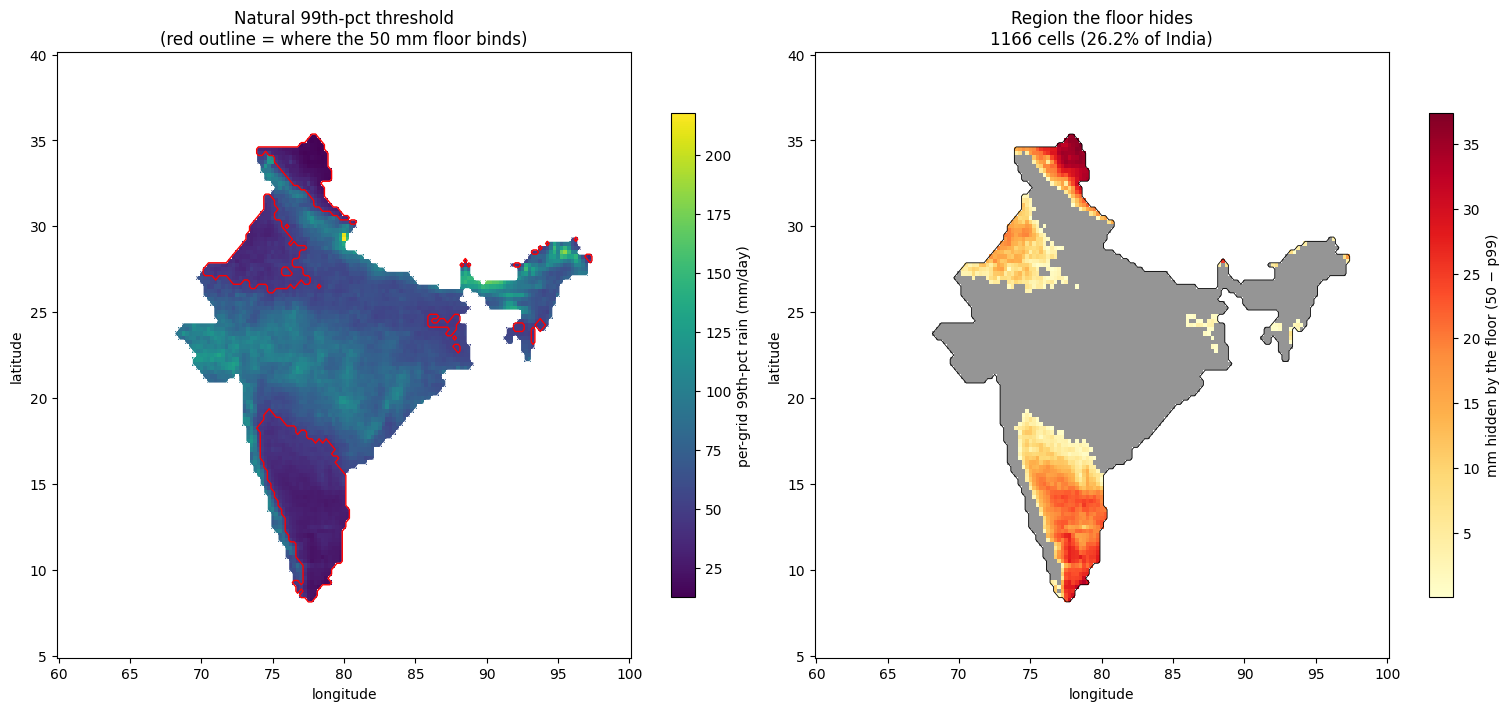

In [11]:
# ── Cell : regions hidden by the 50 mm floor (run AFTER SETUP) ────────────────
import numpy as np, matplotlib.pyplot as plt

FLOOR = 50.0
p99   = np.where(india_mask, per_grid_99, np.nan)
binds = india_mask & (per_grid_99 < FLOOR)
gap   = np.where(binds, FLOOR - per_grid_99, np.nan)

n_india, n_binds = int(india_mask.sum()), int(binds.sum())
print(f"India cells             : {n_india}")
print(f"cells where floor binds : {n_binds}  ({100*n_binds/n_india:.1f}% of India)")
print(f"per_grid_99 over India  : min={np.nanmin(p99):.1f}  median={np.nanmedian(p99):.1f}  "
      f"max={np.nanmax(p99):.1f} mm")
print(f"max amount hidden       : {np.nanmax(gap):.1f} mm")

LON, LAT = np.meshgrid(lon, lat)
fig, axes = plt.subplots(1, 2, figsize=(15, 7), constrained_layout=True)

ax = axes[0]
pm = ax.pcolormesh(LON, LAT, p99, cmap='viridis', shading='auto')
ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='white', linewidths=0.6)
ax.contour(LON, LAT, binds.astype(int),      levels=[0.5], colors='red',   linewidths=1.0)
fig.colorbar(pm, ax=ax, label='per-grid 99th-pct rain (mm/day)', shrink=0.8)
ax.set_title('Natural 99th-pct threshold\n(red outline = where the 50 mm floor binds)')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')

ax = axes[1]
base = np.where(india_mask & ~binds, 0.0, np.nan)
ax.pcolormesh(LON, LAT, base, cmap='Greys', vmin=-1, vmax=1, shading='auto')
pm2 = ax.pcolormesh(LON, LAT, gap, cmap='YlOrRd', shading='auto')
ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='black', linewidths=0.6)
fig.colorbar(pm2, ax=ax, label='mm hidden by the floor (50 − p99)', shrink=0.8)
ax.set_title(f'Region the floor hides\n{n_binds} cells ({100*n_binds/n_india:.1f}% of India)')
ax.set_xlabel('longitude'); ax.set_ylabel('latitude')
plt.show()

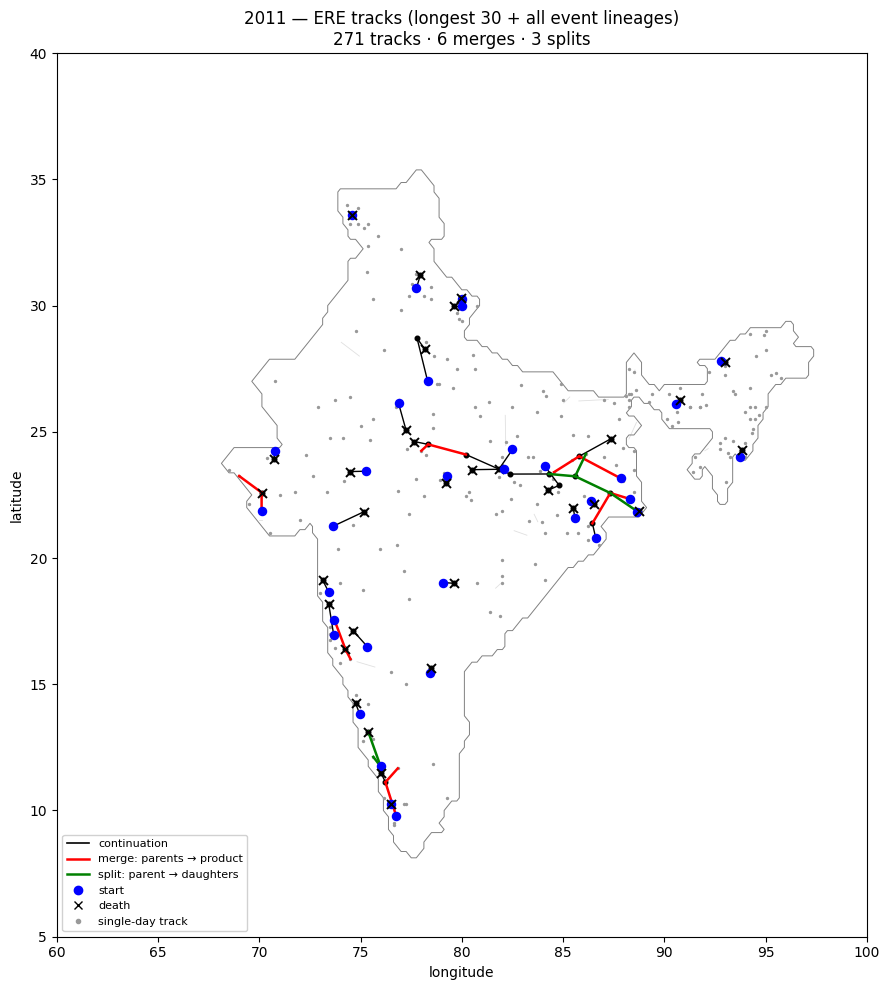

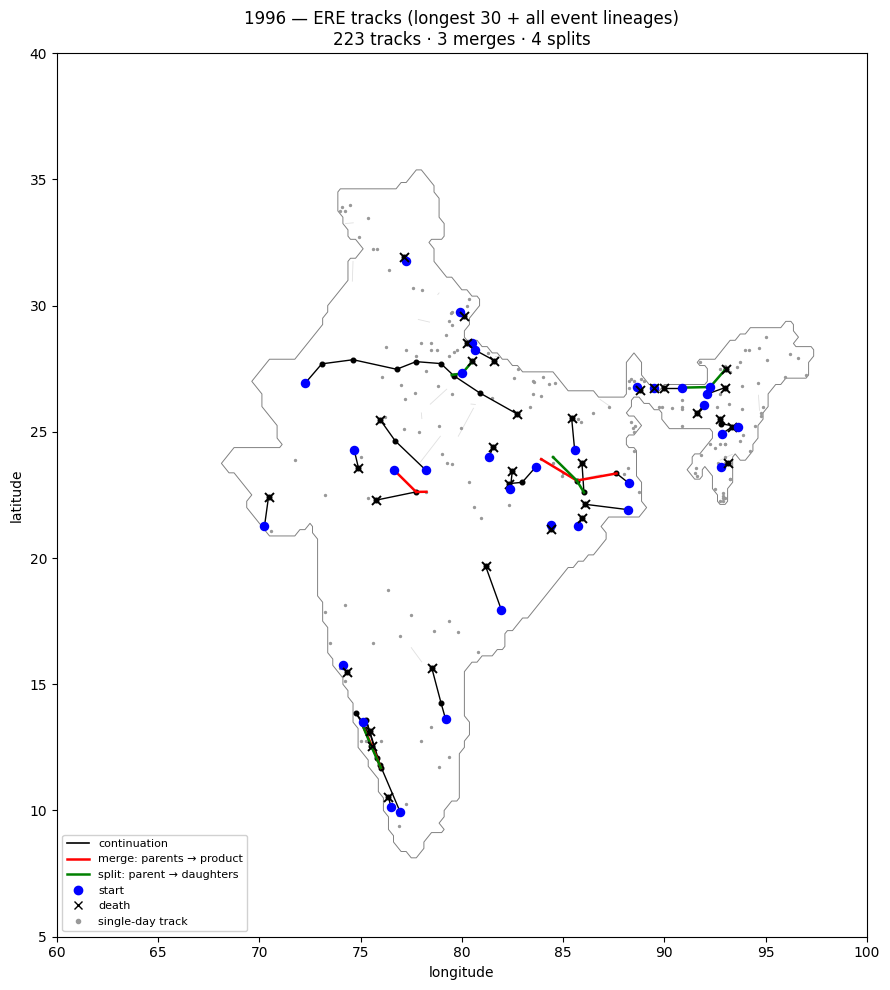

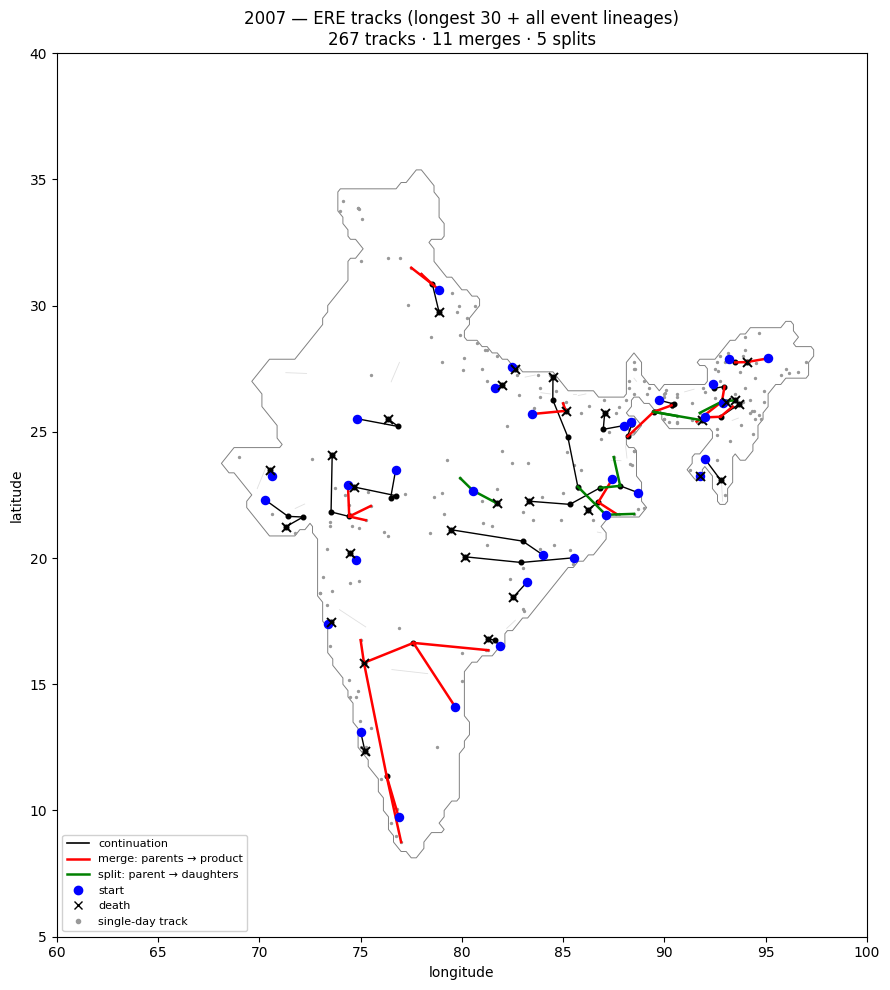

In [12]:
# ── Cell : full-lineage track map (run AFTER the tracker cell) ────────────────
#   black line  = continuation         blue dot = track start
#   black x     = death (natural_death / domain_exit only)
#   red lines   = merge: EVERY parent(T) -> product(T+1), then black
#   green lines = split: parent(T) -> EVERY daughter(T+1); black via dominant daughter
#   grey dots   = single-day tracks    faint grey = other multiday tracks (context)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

_pos = {(int(r.track_num), r.date): (r.centroid_lon, r.centroid_lat)
        for r in stats_mean.itertuples(index=False)}
def _prev(d):
    return (pd.to_datetime(str(d), format='%Y%m%d') - pd.Timedelta(days=1)).strftime('%Y%m%d')

DEATHS = ('natural_death', 'domain_exit')   # merge_death deliberately excluded

def plot_year(year, n_longest=30, context=True):
    syr    = summary_mean[summary_mean['year'] == year]
    multid = syr[syr['duration'] > 1].sort_values('duration', ascending=False)
    me = merge_mean[merge_mean.year == year] if len(merge_mean) else merge_mean.iloc[0:0]
    se = split_mean[split_mean.year == year] if len(split_mean) else split_mean.iloc[0:0]

    focus = set(multid.head(n_longest)['track_num'].astype(int))
    dur   = dict(zip(syr['track_num'].astype(int), syr['duration']))
    def add_md(tn):
        if dur.get(int(tn), 1) > 1: focus.add(int(tn))
    for r in me.itertuples(index=False):
        add_md(r.dominant_track)
        for t in str(r.absorbed_tracks).split(','):
            if t.strip(): add_md(int(t))
    for r in se.itertuples(index=False):
        add_md(r.parent_track)
        for t in str(r.child_tracks).split(','):
            if t.strip(): add_md(int(t))

    singles     = syr[(syr['duration'] == 1) & (~syr['track_num'].isin(focus))]['track_num'].tolist()
    context_tns = [tn for tn in multid['track_num'].astype(int).tolist() if tn not in focus]

    flagged = {}
    for r in me.itertuples(index=False): flagged[(int(r.dominant_track), str(r.date))] = 'red'
    for r in se.itertuples(index=False): flagged[(int(r.parent_track),   str(r.date))] = 'green'

    fig, ax = plt.subplots(figsize=(9, 10))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

    if context:
        for tn in context_tns:
            g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track')
            ax.plot(g.centroid_lon, g.centroid_lat, '-', color='0.88', lw=0.6, zorder=1)
    if singles:
        sd = stats_mean[stats_mean.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=8, color='0.6', marker='.', zorder=2)

    for tn in focus:
        g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
        if len(g) == 0: continue
        lons, lats, dates = g['centroid_lon'].values, g['centroid_lat'].values, g['date'].values
        for i in range(1, len(g)):
            if flagged.get((tn, str(dates[i]))) is not None: continue   # coloured step -> skip black
            ax.plot([lons[i-1], lons[i]], [lats[i-1], lats[i]], '-', color='black', lw=1.0, zorder=2)
        ax.scatter(lons, lats, s=11, color='black', zorder=3)
        ax.scatter(lons[0], lats[0], s=34, color='blue', zorder=6)
        if g.iloc[-1]['end_type'] in DEATHS:
            ax.scatter(lons[-1], lats[-1], s=42, marker='x', color='black', lw=1.4, zorder=6)

    for r in me.itertuples(index=False):                       # RED merges
        product = _pos.get((int(r.dominant_track), str(r.date)))
        if product is None: continue
        parents = [int(r.dominant_track)] + [int(t) for t in str(r.absorbed_tracks).split(',') if t.strip()]
        for p in parents:
            src = _pos.get((p, _prev(r.date)))
            if src: ax.plot([src[0], product[0]], [src[1], product[1]], '-', color='red', lw=1.8, zorder=5)

    for r in se.itertuples(index=False):                       # GREEN splits
        src = _pos.get((int(r.parent_track), _prev(r.date)))
        if src is None: continue
        daughters = [int(r.parent_track)] + [int(t) for t in str(r.child_tracks).split(',') if t.strip()]
        for dt in daughters:
            tgt = _pos.get((dt, str(r.date)))
            if tgt: ax.plot([src[0], tgt[0]], [src[1], tgt[1]], '-', color='green', lw=1.8, zorder=5)

    ax.legend(handles=[
        Line2D([0],[0], color='black', lw=1.2, label='continuation'),
        Line2D([0],[0], color='red',   lw=1.8, label='merge: parents → product'),
        Line2D([0],[0], color='green', lw=1.8, label='split: parent → daughters'),
        Line2D([0],[0], marker='o', color='blue',  lw=0, label='start'),
        Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
        Line2D([0],[0], marker='.', color='0.6',   lw=0, label='single-day track'),
    ], loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"{year} — ERE tracks (longest {min(n_longest, len(multid))} + all event lineages)\n"
                 f"{len(syr)} tracks · {len(me)} merges · {len(se)} splits")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()

for yr in (2011, 1996, 2007):
    plot_year(yr, n_longest=30, context=True)

In [13]:
# ── WIND CELL 1 : per-step alignment engine (run after tracker + wind load) ──
import numpy as np, pandas as pd

YEARS, N_LONGEST, CELL_DEG = [2011, 1996], 8, 0.25
KM_LAT = 110.574
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}

sel = (summary_mean[(summary_mean.year.isin(YEARS)) & (summary_mean.duration > 1)]
       .sort_values(['year', 'duration'], ascending=[True, False])
       .groupby('year').head(N_LONGEST))
sel_tracks = set(sel.track_num.astype(int))
print(f"selected {len(sel_tracks)} tracks ({YEARS}, top {N_LONGEST}/yr, "
      f"durations {sel.duration.min()}–{sel.duration.max()} d)")

def footprint_wind(date_str, day_lbl):
    t = date_to_idx[date_str]; m = (Label8[t] == int(day_lbl))
    if m.sum() == 0: return np.nan, np.nan
    return float(u_wind[t][m].mean()), float(v_wind[t][m].mean())

rows = []
for tn in sel_tracks:
    g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    for k in range(len(g) - 1):
        a, b = g.iloc[k], g.iloc[k + 1]                       # T (from), T+1 (to)
        mlat = 0.5 * (a.centroid_lat + b.centroid_lat)
        e_km = (b.centroid_lon - a.centroid_lon) * 111.320 * np.cos(np.radians(mlat))
        n_km = (b.centroid_lat - a.centroid_lat) * KM_LAT
        step_km = float(np.hypot(e_km, n_km))
        d_e, d_n = e_km * 1000 / 86400, n_km * 1000 / 86400   # m/s
        d_spd = float(np.hypot(d_e, d_n))
        Wu, Wv = footprint_wind(a.date, a.day_lbl); W_spd = float(np.hypot(Wu, Wv))
        bd, bw = np.degrees(np.arctan2(d_e, d_n)), np.degrees(np.arctan2(Wu, Wv))
        dlt = (bd - bw + 180) % 360 - 180                     # signed: motion − wind
        r_eq_km = float(np.sqrt(a['size'] * CELL_DEG**2 / np.pi) * KM_LAT)
        stationary = step_km < max(r_eq_km, 0.5 * CELL_DEG * KM_LAT)
        rows.append(dict(track_num=tn, year=int(a.year), dot=int(a.day_of_track),
            date_T=a.date, date_T1=b.date, link=b.link_type, size_T=int(a['size']),
            r_eq_km=round(r_eq_km, 1), step_km=round(step_km, 1),
            d_ms=round(d_spd, 2), W_ms=round(W_spd, 2),
            ratio=round(d_spd / W_spd, 3) if W_spd > 0 else np.nan,
            bear_d=round(bd, 1), bear_W=round(bw, 1), delta=round(dlt, 1),
            cos=round(np.cos(np.radians(dlt)), 3), stationary=bool(stationary)))

wind_steps = pd.DataFrame(rows)
clean = wind_steps[(wind_steps.link == 'overlap') & (~wind_steps.stationary)].copy()
evt   = wind_steps[wind_steps.link.isin(['merge', 'split'])]
print(f"\nsteps {len(wind_steps)} | clean {len(clean)} | merge/split {len(evt)} | "
      f"stationary {int(wind_steps.stationary.sum())}\n")

longest = int(sel.sort_values('duration', ascending=False).iloc[0].track_num)
print(f"longest track {longest} step-by-step:")
cols = ['dot','date_T','date_T1','link','size_T','step_km','d_ms','W_ms',
        'ratio','bear_d','bear_W','delta','cos','stationary']
print(wind_steps[wind_steps.track_num == longest][cols].to_string(index=False))

def circ(df, weighted=True):
    th = np.radians(df.delta.values); w = df.d_ms.values if weighted else np.ones(len(df))
    C, S = np.sum(w*np.cos(th)), np.sum(w*np.sin(th))
    return np.hypot(C, S)/np.sum(w), np.degrees(np.arctan2(S, C))

R_w, off_w = circ(clean, True); R_u, _ = circ(clean, False)
n = len(clean); p_ray = float(np.exp(-n * R_u**2))
print("\n===============  POOLED WIND VALIDATION (clean steps)  ===============")
print(f"  n clean steps              : {n}")
print(f"  mean cos(Δ)                : {clean.cos.mean():+.3f}   (1=aligned,0=random,-1=opposed)")
print(f"  frac |Δ|<45° / <90°        : {100*(clean.delta.abs()<45).mean():.0f}% / {100*(clean.delta.abs()<90).mean():.0f}%")
print(f"  resultant length R (wtd)   : {R_w:.3f}   (unwtd {R_u:.3f})")
print(f"  mean offset from wind       : {off_w:+.1f}°   [neg = left/NW of flow = beta]")
print(f"  Rayleigh p (uniformity)    : {p_ray:.4f}   ({'REJECT uniform ✓' if p_ray<0.05 else 'cannot reject ✗'})")
print(f"  median speed ratio |d|/|W| : {clean.ratio.median():.2f}   (expect 0.3–0.7)")
if len(evt):
    print(f"  contrast — merge/split mean cos(Δ) = {evt.cos.mean():+.3f}  (should be WORSE)")

selected 16 tracks ([2011, 1996], top 8/yr, durations 2–9 d)

steps 47 | clean 21 | merge/split 11 | stationary 17

longest track 3882 step-by-step:
 dot   date_T  date_T1    link  size_T  step_km  d_ms  W_ms  ratio  bear_d  bear_W  delta    cos  stationary
   0 19960620 19960621 overlap      47    118.2  1.37  7.76  0.176    43.8  -124.4  168.2 -0.979       False
   1 19960621 19960622 overlap      52    153.5  1.78  5.86  0.303    83.2   126.2  -42.9  0.732       False
   2 19960622 19960623 overlap      71    216.0  2.50 14.38  0.174   101.2    92.6    8.6  0.989       False
   3 19960623 19960624 overlap      34    100.1  1.16 12.49  0.093    70.5    95.7  -25.2  0.905       False
   4 19960624 19960625 overlap      74    121.3  1.40  6.44  0.218    94.0   110.8  -16.8  0.957        True
   5 19960625 19960626 overlap      69     82.3  0.95  5.26  0.181   130.1   112.4   17.7  0.953        True
   6 19960626 19960627 overlap      37    148.0  1.71 11.59  0.148   120.6   122.0   -1.

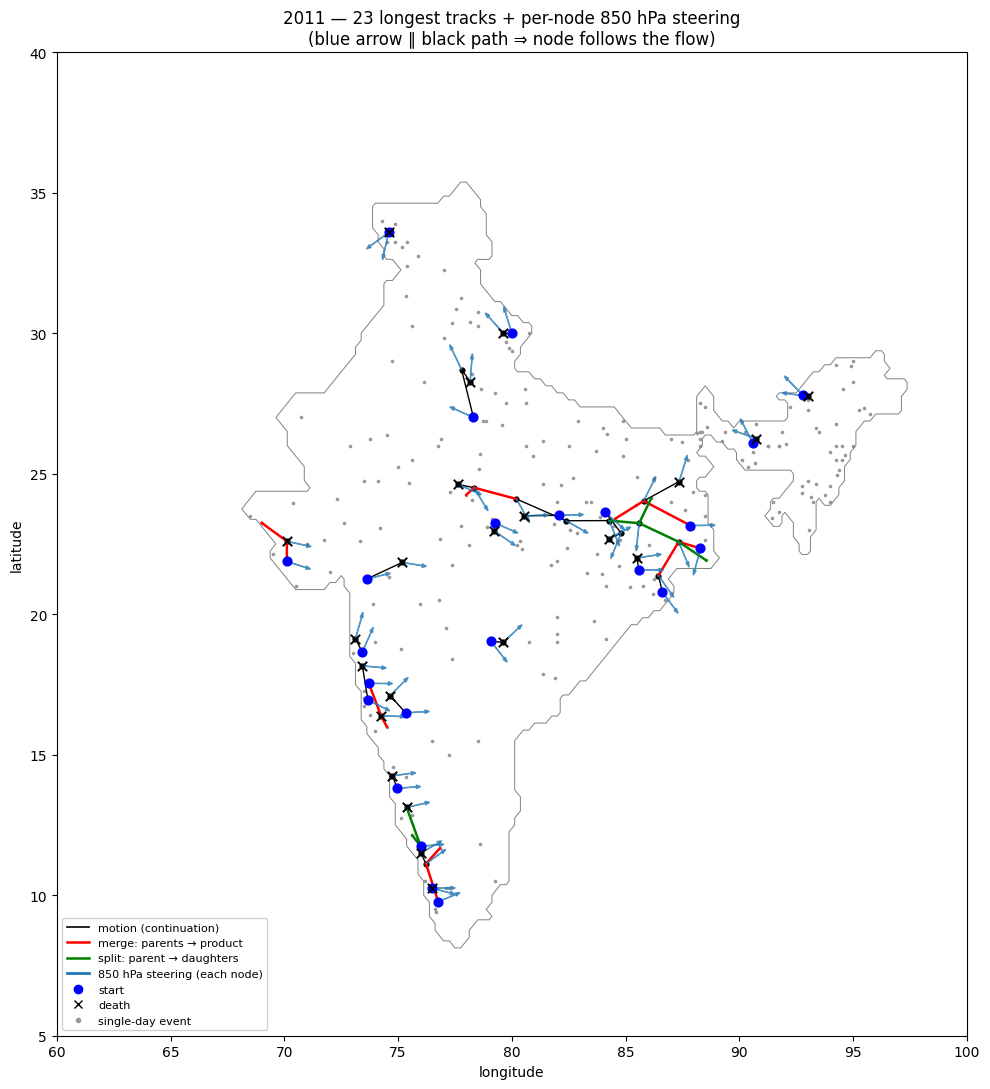

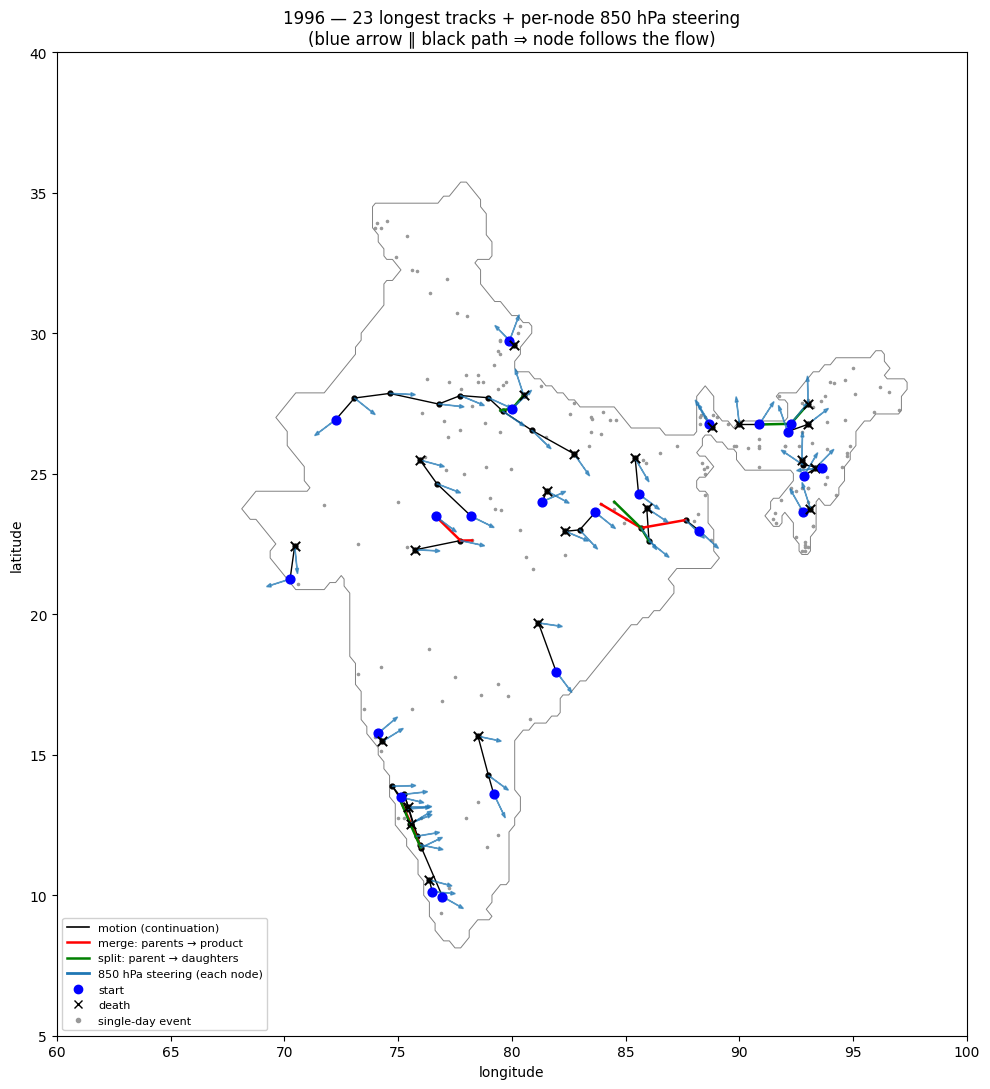

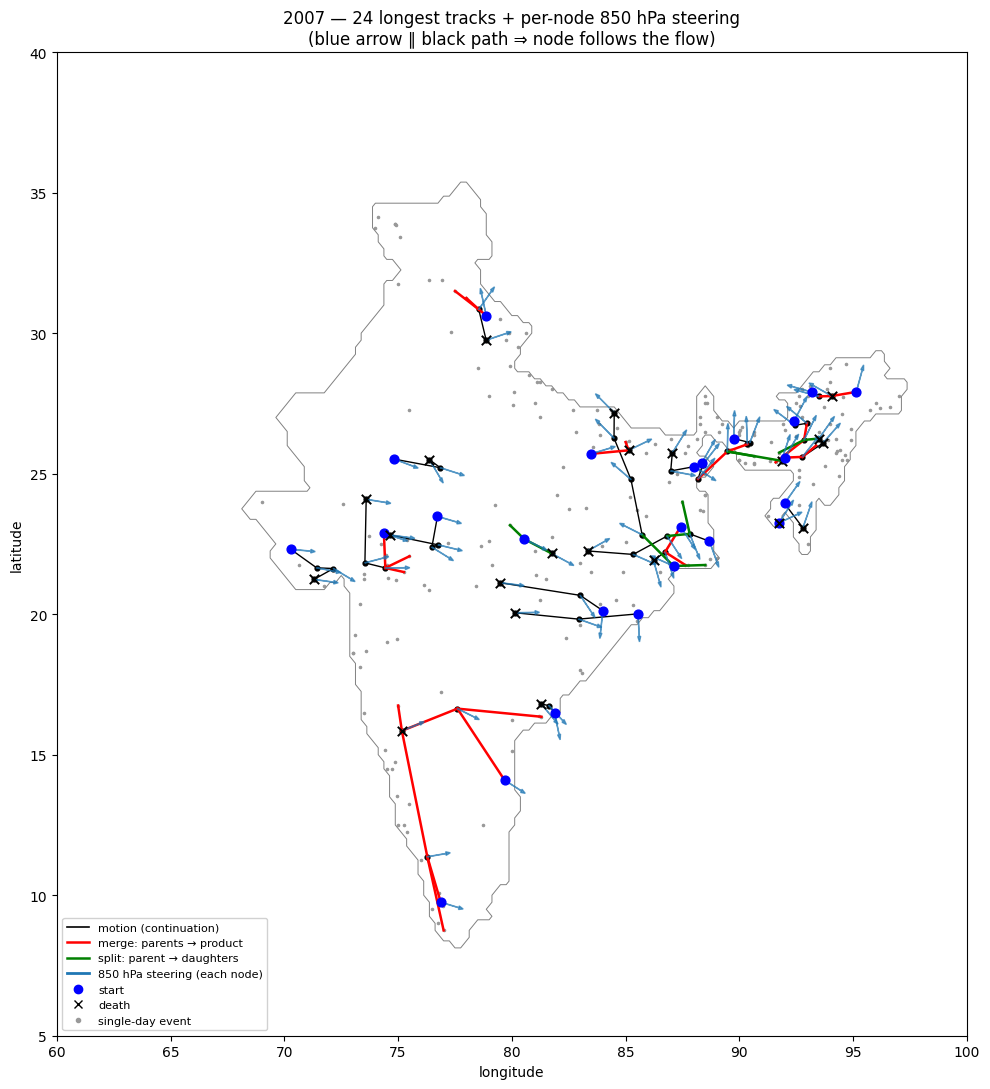

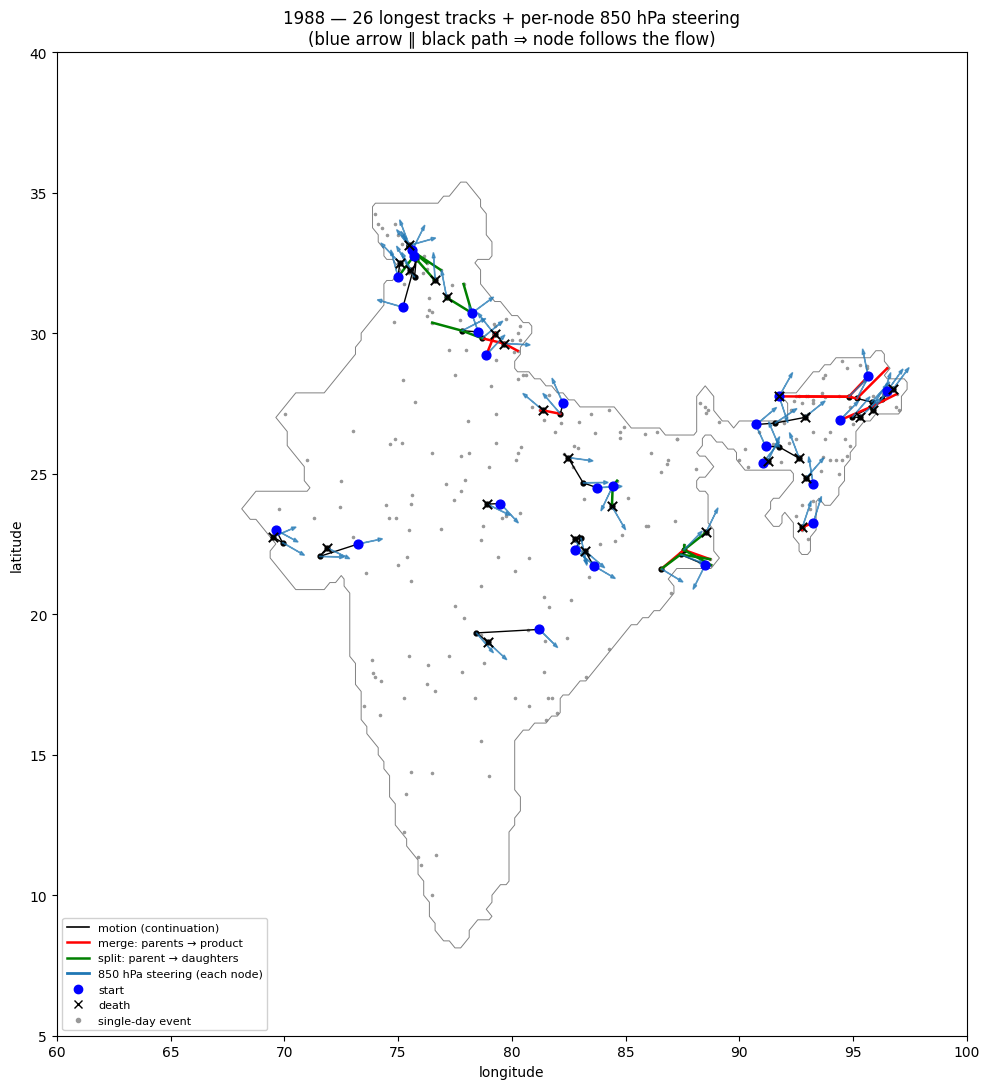

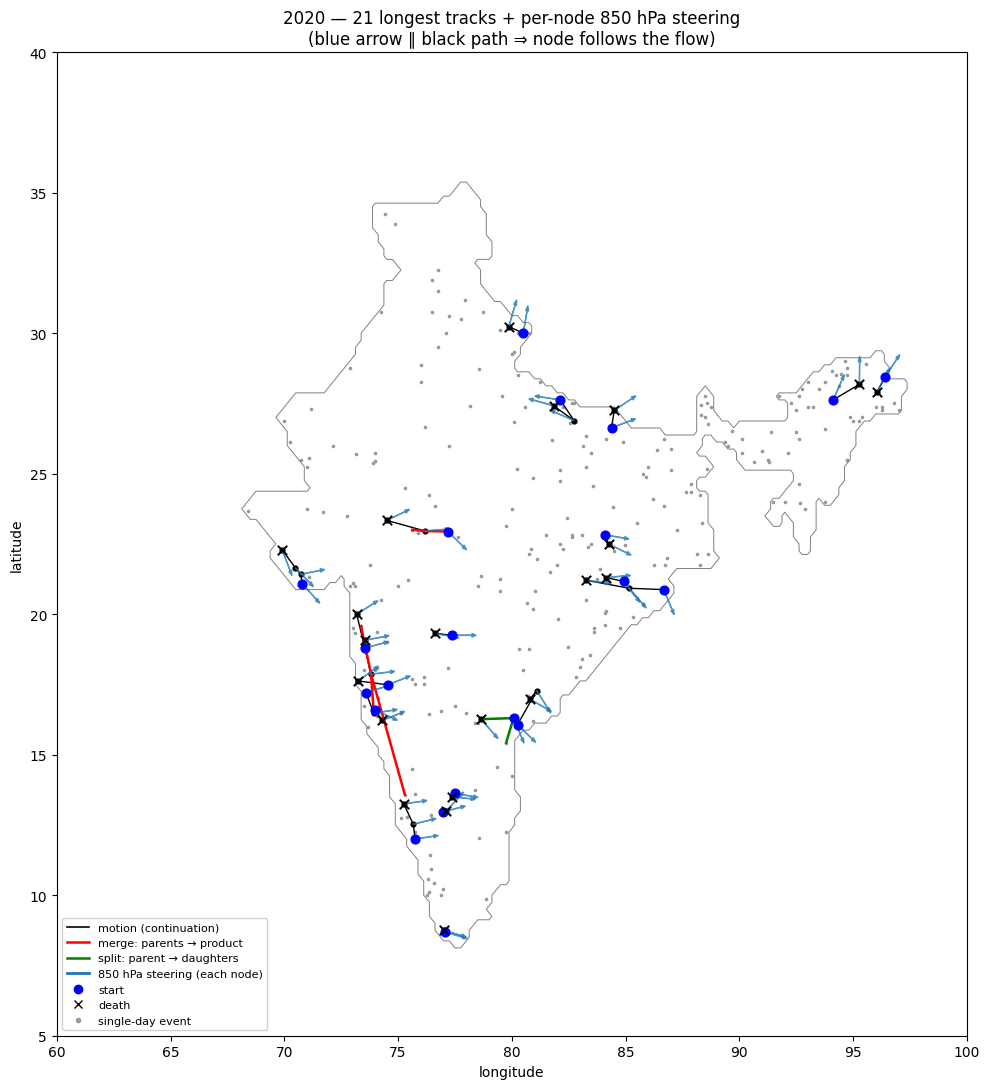

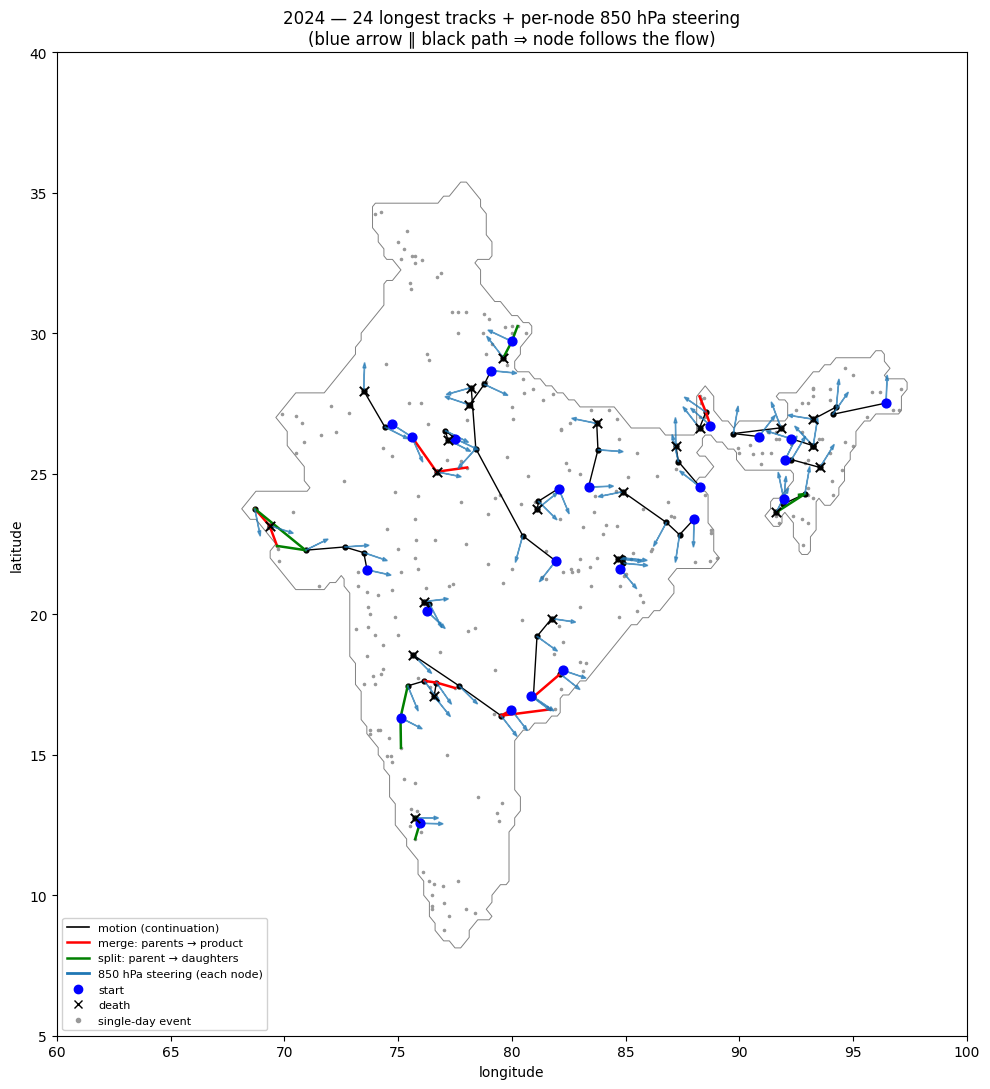

In [18]:
# ── WIND MAP : 20 longest/yr · per-node 850 steering · full merge/split lineage
#   black = continuation   blue = start   black x = death (natural/domain only)
#   red   = merge: EVERY parent(T) → product(T+1)
#   green = split: parent(T) → EVERY daughter(T+1); black continues via dominant
#   blue arrow at EVERY focus node = where that node 'wants' to go (footprint wind)
#   grey dots in background = ALL single-day events that year
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

YEARS, N_LONGEST = [2011, 1996, 2007, 1988, 2020, 2024], 20
ARROW_DEG, DEATHS = 1.0, ('natural_death', 'domain_exit')   # arrow = direction only
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}
_pos = {(int(r.track_num), r.date): (r.centroid_lon, r.centroid_lat)
        for r in stats_mean.itertuples(index=False)}

def footprint_wind(date_str, day_lbl):
    t = date_to_idx[date_str]; m = (Label8[t] == int(day_lbl))
    if m.sum() == 0: return np.nan, np.nan
    return float(u_wind[t][m].mean()), float(v_wind[t][m].mean())
def _prev(d):
    return (pd.to_datetime(str(d), format='%Y%m%d') - pd.Timedelta(days=1)).strftime('%Y%m%d')

def wind_lineage_map(year, n_longest=N_LONGEST):
    syr    = summary_mean[summary_mean.year == year]
    multid = syr[syr.duration > 1].sort_values('duration', ascending=False)
    dur    = dict(zip(syr.track_num.astype(int), syr.duration))
    focus  = set(multid.head(n_longest).track_num.astype(int))

    me = merge_mean[merge_mean.year == year] if len(merge_mean) else merge_mean.iloc[0:0]
    se = split_mean[split_mean.year == year] if len(split_mean) else split_mean.iloc[0:0]
    def add_md(tn):                                   # multiday participants drawn as tracks
        if dur.get(int(tn), 1) > 1: focus.add(int(tn))
    for r in me.itertuples(index=False):
        focus.add(int(r.dominant_track))
        for t in str(r.absorbed_tracks).split(','):
            if t.strip(): add_md(t)
    for r in se.itertuples(index=False):
        focus.add(int(r.parent_track))
        for t in str(r.child_tracks).split(','):
            if t.strip(): add_md(t)

    flagged = {}
    for r in me.itertuples(index=False): flagged[(int(r.dominant_track), str(r.date))] = 'red'
    for r in se.itertuples(index=False): flagged[(int(r.parent_track),   str(r.date))] = 'green'
    singles = syr[syr.duration == 1].track_num.tolist()

    fig, ax = plt.subplots(figsize=(10, 11))
    LON, LAT = np.meshgrid(lon, lat)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

    if singles:                                       # ALL single-day events (background)
        sd = stats_mean[stats_mean.track_num.isin(singles)]
        ax.scatter(sd.centroid_lon, sd.centroid_lat, s=10, color='0.6', marker='.', zorder=1)

    for tn in focus:
        g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
        if len(g) == 0: continue
        lons, lats, dates = g.centroid_lon.values, g.centroid_lat.values, g.date.values
        for k in range(1, len(g)):
            if flagged.get((tn, str(dates[k]))) is not None: continue   # coloured step → skip black
            ax.plot([lons[k-1], lons[k]], [lats[k-1], lats[k]], '-', color='black', lw=1.0, zorder=3)
        ax.scatter(lons, lats, s=12, color='black', zorder=4)
        ax.scatter(lons[0], lats[0], s=40, color='blue', zorder=6)
        if g.iloc[-1].end_type in DEATHS:
            ax.scatter(lons[-1], lats[-1], s=46, marker='x', color='black', lw=1.4, zorder=6)
        for r in g.itertuples(index=False):           # per-node steering arrow
            Wu, Wv = footprint_wind(r.date, r.day_lbl); sp = np.hypot(Wu, Wv)
            if not np.isfinite(sp) or sp == 0: continue
            dx = ARROW_DEG * (Wu/sp) / np.cos(np.radians(r.centroid_lat))
            dy = ARROW_DEG * (Wv/sp)
            ax.arrow(r.centroid_lon, r.centroid_lat, dx, dy, color='tab:blue',
                     width=0.011, head_width=0.13, length_includes_head=True, zorder=5, alpha=0.7)

    for r in me.itertuples(index=False):              # RED merges: all parents → product
        product = _pos.get((int(r.dominant_track), str(r.date)))
        if product is None: continue
        parents = [int(r.dominant_track)] + [int(t) for t in str(r.absorbed_tracks).split(',') if t.strip()]
        for p in parents:
            src = _pos.get((p, _prev(r.date)))
            if src: ax.plot([src[0], product[0]], [src[1], product[1]], '-', color='red', lw=1.8, zorder=4)

    for r in se.itertuples(index=False):              # GREEN splits: parent → all daughters
        src = _pos.get((int(r.parent_track), _prev(r.date)))
        if src is None: continue
        daughters = [int(r.parent_track)] + [int(t) for t in str(r.child_tracks).split(',') if t.strip()]
        for dt in daughters:
            tgt = _pos.get((dt, str(r.date)))
            if tgt: ax.plot([src[0], tgt[0]], [src[1], tgt[1]], '-', color='green', lw=1.8, zorder=4)

    ax.legend(handles=[
        Line2D([0],[0], color='black', lw=1.2, label='motion (continuation)'),
        Line2D([0],[0], color='red',   lw=1.8, label='merge: parents → product'),
        Line2D([0],[0], color='green', lw=1.8, label='split: parent → daughters'),
        Line2D([0],[0], color='tab:blue', lw=2, label='850 hPa steering (each node)'),
        Line2D([0],[0], marker='o', color='blue',  lw=0, label='start'),
        Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
        Line2D([0],[0], marker='.', color='0.6',   lw=0, label='single-day event'),
    ], loc='lower left', fontsize=8, framealpha=0.9)
    ax.set_title(f"{year} — {len(focus)} longest tracks + per-node 850 hPa steering\n"
                 f"(blue arrow ∥ black path ⇒ node follows the flow)")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    plt.tight_layout(); plt.show()

for y in YEARS:
    wind_lineage_map(y)

top 15 tracks: durations 6–9 d, years [np.int64(1991), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(2002), np.int64(2004), np.int64(2006), np.int64(2011), np.int64(2016), np.int64(2017), np.int64(2019), np.int64(2021)]


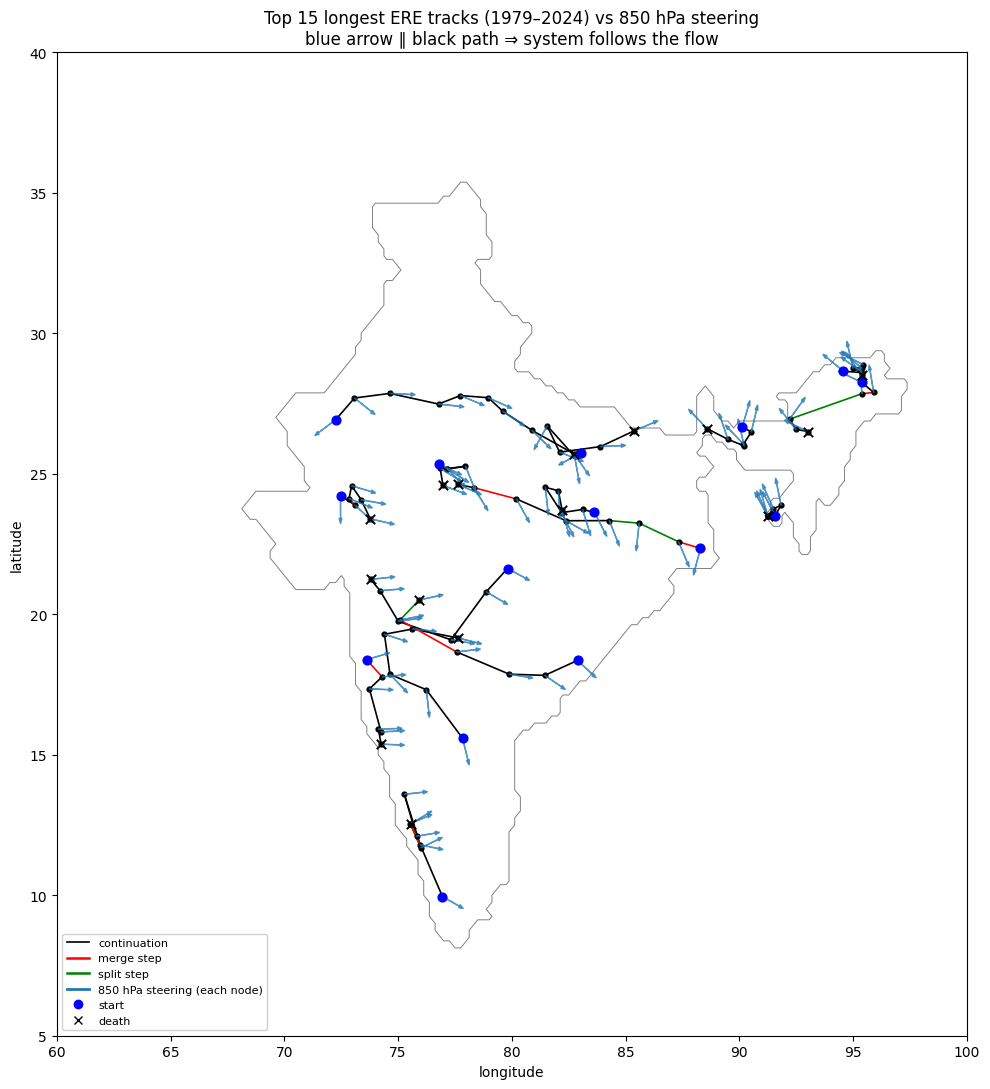

In [24]:
# ── TOP-30 tracks across ALL years : motion vs 850 steering ──────────────────
#   black = continuation   red = merge step   green = split step   (dominant only)
#   blue dot = start   black x = death (natural/domain)   blue arrow = node steering
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

N_TOP, ARROW_DEG, DEATHS = 15, 1.0, ('natural_death', 'domain_exit')
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}

def footprint_wind(date_str, day_lbl):
    t = date_to_idx[date_str]; m = (Label8[t] == int(day_lbl))
    if m.sum() == 0: return np.nan, np.nan
    return float(u_wind[t][m].mean()), float(v_wind[t][m].mean())

top30 = summary_mean.sort_values('duration', ascending=False).head(N_TOP)
top30_set = set(top30.track_num.astype(int))
print(f"top {N_TOP} tracks: durations {int(top30.duration.min())}–{int(top30.duration.max())} d, "
      f"years {sorted(top30.year.unique())}")

fig, ax = plt.subplots(figsize=(10, 11))
LON, LAT = np.meshgrid(lon, lat)
ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='grey', linewidths=0.7)

for tn in top30_set:
    g = stats_mean[stats_mean.track_num == tn].sort_values('day_of_track').reset_index(drop=True)
    if len(g) == 0: continue
    lons, lats = g.centroid_lon.values, g.centroid_lat.values
    for k in range(1, len(g)):
        c = {'merge': 'red', 'split': 'green'}.get(g.iloc[k].link_type, 'black')
        ax.plot([lons[k-1], lons[k]], [lats[k-1], lats[k]], '-', color=c, lw=1.2, zorder=3)
    ax.scatter(lons, lats, s=12, color='black', zorder=4)
    ax.scatter(lons[0], lats[0], s=40, color='blue', zorder=6)
    if g.iloc[-1].end_type in DEATHS:
        ax.scatter(lons[-1], lats[-1], s=46, marker='x', color='black', lw=1.4, zorder=6)
    for r in g.itertuples(index=False):
        Wu, Wv = footprint_wind(r.date, r.day_lbl); sp = np.hypot(Wu, Wv)
        if not np.isfinite(sp) or sp == 0: continue
        dx = ARROW_DEG * (Wu/sp) / np.cos(np.radians(r.centroid_lat)); dy = ARROW_DEG * (Wv/sp)
        ax.arrow(r.centroid_lon, r.centroid_lat, dx, dy, color='tab:blue',
                 width=0.011, head_width=0.13, length_includes_head=True, zorder=5, alpha=0.7)

ax.legend(handles=[
    Line2D([0],[0], color='black', lw=1.2, label='continuation'),
    Line2D([0],[0], color='red',   lw=1.8, label='merge step'),
    Line2D([0],[0], color='green', lw=1.8, label='split step'),
    Line2D([0],[0], color='tab:blue', lw=2, label='850 hPa steering (each node)'),
    Line2D([0],[0], marker='o', color='blue',  lw=0, label='start'),
    Line2D([0],[0], marker='x', color='black', lw=0, label='death'),
], loc='lower left', fontsize=8, framealpha=0.9)
ax.set_title(f"Top {N_TOP} longest ERE tracks (1979–2024) vs 850 hPa steering\n"
             f"blue arrow ∥ black path ⇒ system follows the flow")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
plt.tight_layout(); plt.show()

In [25]:
# ── FULL multiday wind analysis : per-step table + pooled + stratified ───────
import numpy as np, pandas as pd
KM_LAT, CELL_DEG = 110.574, 0.25
date_to_idx = {ts.strftime('%Y%m%d'): i for i, ts in enumerate(times_pd)}

def footprint_wind(date_str, day_lbl):
    t = date_to_idx[date_str]; m = (Label8[t] == int(day_lbl))
    if m.sum() == 0: return np.nan, np.nan
    return float(u_wind[t][m].mean()), float(v_wind[t][m].mean())

md_set = set(summary_mean[summary_mean.duration > 2].track_num.astype(int))   # >2 days
sub = stats_mean[stats_mean.track_num.isin(md_set)].sort_values(['track_num','day_of_track'])
print(f"multiday tracks (dur>2): {len(md_set)}   obj-days: {len(sub)}")

rows = []
for tn, g in sub.groupby('track_num'):
    g = g.reset_index(drop=True)
    for k in range(len(g)-1):
        a, b = g.iloc[k], g.iloc[k+1]
        mlat = 0.5*(a.centroid_lat+b.centroid_lat)
        e = (b.centroid_lon-a.centroid_lon)*111.320*np.cos(np.radians(mlat))
        n = (b.centroid_lat-a.centroid_lat)*KM_LAT
        step_km = np.hypot(e,n); d_e,d_n = e*1000/86400, n*1000/86400; d_spd = np.hypot(d_e,d_n)
        Wu,Wv = footprint_wind(a.date, a.day_lbl); W_spd = np.hypot(Wu,Wv)
        dlt = (np.degrees(np.arctan2(d_e,d_n)) - np.degrees(np.arctan2(Wu,Wv)) + 180)%360 - 180
        sh = int(b.link_sh); szT, szT1 = int(a['size']), int(b['size'])
        r_eq = np.sqrt(szT*CELL_DEG**2/np.pi)*KM_LAT
        rows.append(dict(tn=int(tn), year=int(a.year), dur=len(g), dot=int(a.day_of_track),
            link=b.link_type, birth_step=(a.day_of_track==0),
            step_km=step_km, d_ms=d_spd, W_ms=W_spd,
            ratio=d_spd/W_spd if W_spd>0 else np.nan,
            delta=dlt, cos=np.cos(np.radians(dlt)),
            sh=sh, szT=szT, szT1=szT1,
            f_fwd=sh/szT, f_bwd=sh/szT1, f_min=sh/min(szT,szT1),
            score=float(b.link_score) if b.link_score==b.link_score else np.nan,
            stationary=step_km < max(r_eq, 0.5*CELL_DEG*KM_LAT)))
S = pd.DataFrame(rows)
clean = S[(S.link=='overlap') & (~S.stationary) & (~S.birth_step)].copy()
print(f"steps total {len(S)} | clean {len(clean)} | stationary {int(S.stationary.sum())} "
      f"| birth {int(S.birth_step.sum())} | merge/split {int((S.link!='overlap').sum())}")

def Rp(df):
    if len(df)==0: return np.nan,np.nan,np.nan
    th=np.radians(df.delta.values); C,Sn=np.cos(th).mean(),np.sin(th).mean()
    R=np.hypot(C,Sn); return R, np.degrees(np.arctan2(Sn,C)), float(np.exp(-len(df)*R**2))

R,off,p = Rp(clean)
print("\n========  POOLED (all multiday clean steps)  ========")
print(f"  clean steps        : {len(clean)}")
print(f"  mean cos(Δ)        : {clean.cos.mean():+.3f}")
print(f"  frac |Δ|<90°       : {100*(clean.delta.abs()<90).mean():.0f}%")
print(f"  resultant R        : {R:.3f}   offset {off:+.1f}°")
print(f"  Rayleigh p         : {p:.2e}  ({'significant ✓' if p<0.05 else 'ns ✗'})")
print(f"  median speed ratio : {clean.ratio.median():.2f}")

print("\n--- by DURATION ---")
for lo,hi,lab in [(3,3,'3 d'),(4,4,'4 d'),(5,6,'5–6 d'),(7,99,'7+ d')]:
    c=clean[(clean.dur>=lo)&(clean.dur<=hi)]; r,o,pp=Rp(c)
    print(f"  {lab:6s}: n={len(c):4d}  cos={c.cos.mean():+.2f}  R={r:.2f}  p={pp:.1e}  ratio={c.ratio.median():.2f}")

print("\n--- by STEP DISPLACEMENT (quartiles) ---")
qs=clean.step_km.quantile([0,.25,.5,.75,1.]).values
for i in range(4):
    c=clean[(clean.step_km>=qs[i])&(clean.step_km<=qs[i+1])]; r,o,pp=Rp(c)
    print(f"  {qs[i]:5.0f}-{qs[i+1]:5.0f} km: n={len(c):4d}  cos={c.cos.mean():+.2f}  R={r:.2f}  p={pp:.1e}")

multiday tracks (dur>2): 501   obj-days: 1744
steps total 1243 | clean 313 | stationary 488 | birth 501 | merge/split 200

========  POOLED (all multiday clean steps)  ========
  clean steps        : 313
  mean cos(Δ)        : -0.036
  frac |Δ|<90°       : 48%
  resultant R        : 0.065   offset +123.4°
  Rayleigh p         : 2.63e-01  (ns ✗)
  median speed ratio : 0.16

--- by DURATION ---
  3 d   : n= 152  cos=-0.07  R=0.11  p=1.8e-01  ratio=0.17
  4 d   : n=  85  cos=-0.06  R=0.08  p=5.8e-01  ratio=0.16
  5–6 d : n=  67  cos=+0.02  R=0.02  p=9.8e-01  ratio=0.16
  7+ d  : n=   9  cos=+0.33  R=0.33  p=3.9e-01  ratio=0.17

--- by STEP DISPLACEMENT (quartiles) ---
     19-   93 km: n=  79  cos=+0.04  R=0.04  p=8.9e-01
     93-  131 km: n=  79  cos=+0.13  R=0.14  p=2.1e-01
    131-  187 km: n=  79  cos=+0.03  R=0.06  p=7.7e-01
    187-  482 km: n=  79  cos=-0.32  R=0.34  p=1.1e-04


In [26]:
# ── ALIGNMENT vs OVERLAP : is a well-aligned step also a well-overlapped one? ─
from scipy.stats import spearmanr
print("Spearman correlations (clean non-stationary steps):")
for col,lab in [('f_min','overlap frac (of smaller)'),('score','mean score'),
                ('f_fwd','fwd frac'),('sh','shared cells')]:
    rho,pv = spearmanr(clean[col], clean.cos)
    print(f"  cos(Δ) vs {lab:24s}: rho={rho:+.3f}  p={pv:.1e}")
print(f"  (control)  cos(Δ) vs step_km     : rho={spearmanr(clean.step_km,clean.cos)[0]:+.3f}")
print(f"  (confound) overlap  vs step_km   : rho={spearmanr(clean.f_min,clean.step_km)[0]:+.3f}")

print("\n--- mean cos by OVERLAP bin (median displacement shown to expose confound) ---")
clean['ov_bin'] = pd.qcut(clean.f_min, 4, duplicates='drop')
gtab = clean.groupby('ov_bin', observed=True).agg(
    n=('cos','size'), cos=('cos','mean'),
    R=('delta', lambda x: np.hypot(np.cos(np.radians(x)).mean(), np.sin(np.radians(x)).mean())),
    ov_med=('f_min','median'), step_med=('step_km','median'))
print(gtab.round(3).to_string())

print("\n--- ALIGNED vs ANTI-ALIGNED: do anti-aligned steps have weaker overlap? ---")
for nm,d in [('aligned  (cos> 0.5)', clean[clean.cos> 0.5]),
             ('anti     (cos<-0.5)', clean[clean.cos<-0.5])]:
    print(f"  {nm}: n={len(d):4d}  med f_min={d.f_min.median():.2f}  med sh={d.sh.median():.0f}  "
          f"med step={d.step_km.median():.0f}km  med size={d.szT.median():.0f}")

Spearman correlations (clean non-stationary steps):
  cos(Δ) vs overlap frac (of smaller): rho=-0.051  p=3.7e-01
  cos(Δ) vs mean score              : rho=-0.042  p=4.6e-01
  cos(Δ) vs fwd frac                : rho=-0.008  p=8.9e-01
  cos(Δ) vs shared cells            : rho=-0.152  p=7.0e-03
  (control)  cos(Δ) vs step_km     : rho=-0.180
  (confound) overlap  vs step_km   : rho=-0.410

--- mean cos by OVERLAP bin (median displacement shown to expose confound) ---
                  n    cos      R  ov_med  step_med
ov_bin                                             
(0.0212, 0.208]  79 -0.021  0.026   0.125   175.666
(0.208, 0.351]   79  0.002  0.101   0.286   145.750
(0.351, 0.571]   79 -0.113  0.124   0.500   120.280
(0.571, 1.0]     76 -0.010  0.053   0.974   102.186

--- ALIGNED vs ANTI-ALIGNED: do anti-aligned steps have weaker overlap? ---
  aligned  (cos> 0.5): n= 106  med f_min=0.33  med sh=4  med step=119km  med size=25
  anti     (cos<-0.5): n= 127  med f_min=0.35  med sh=5  